# DOCKER

> Conceptos

Conceptos básicos de Docker

* Imagen → Plantilla lista para ejecutar (ej: python:3.10).

* Contenedor → Ejecución en vivo de la imagen.

* Dockerfile → Archivo donde escribes cómo construir tu propia imagen.

* Volumen → Carpeta compartida entre tu PC y el contenedor.

* Red → Forma en que los contenedores se comunican entre sí.

***Ejemplo***

La solución: Docker

* Docker permite empaquetar tu aplicación junto con todo lo necesario para ejecutarla en una imagen.

* Una imagen = receta (como una foto congelada de un sistema operativo + tus dependencias).

* Un contenedor = ejecución en vivo de esa imagen (como una “instancia” de esa foto).

Ejemplo mental:

* Imagen = receta de un pastel 🍰.

* Contenedor = el pastel ya horneado y servido 🎂.

* Puedes hacer muchos pasteles (contenedores) a partir de la misma receta (imagen).

Abrir docker desktop

> pruebas docker para verificar instalacion

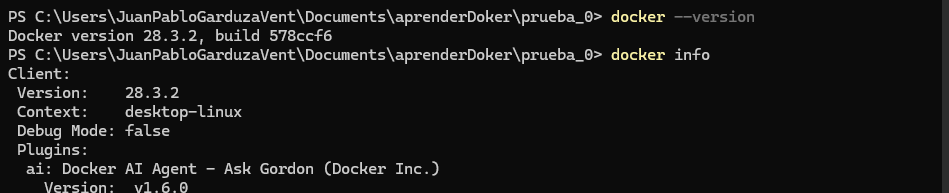

> ejecutar python dentro de un contenedor

* docker run → crea y ejecuta un contenedor.

* -it → modo interactivo con terminal.

* python:3.10 → es la imagen oficial de Python 3.10 (si no la tienes, se descarga).

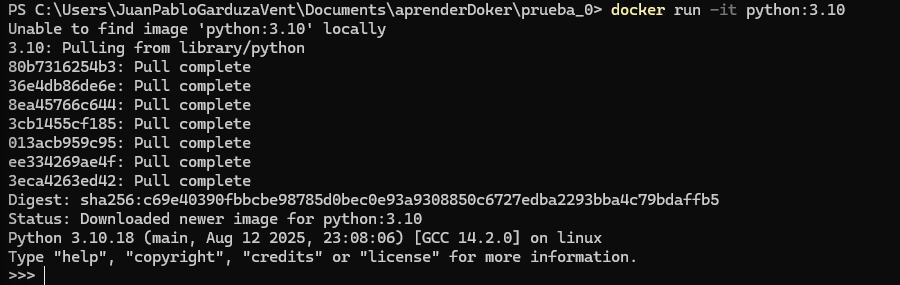

> Ver los contenedores en ejecución (incluso los que ya se detuvieron):

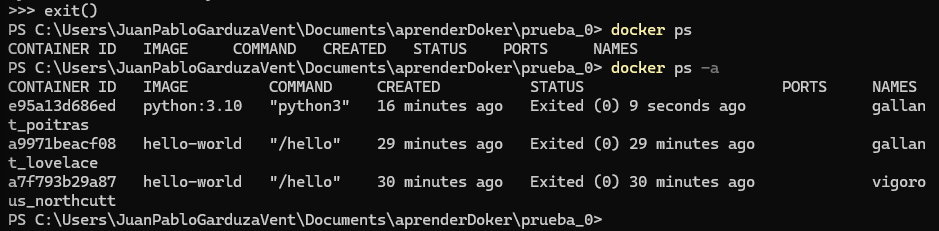

> Detener contenedor

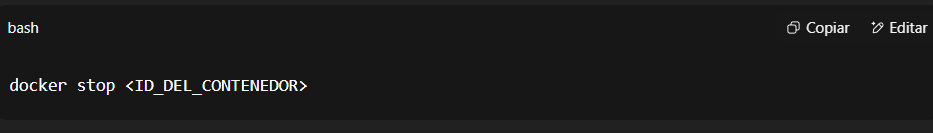

> *RESUMEN*

* Docker
    * Tecnologia que permite empaquetar aplicacion junto con todo lo necesario (librerias, dependcias, sistema base) para que funione igual, sin importar la maquina que se ejecute.

* Imagen 
    * Es como una receta congelada
    * Define que sistema base, que dependencias y que configuraciones tendra la app
    * No se ejecuta por si sola, es solo el "molde"
    * Ejemplo: python:3.10, mysql:8, nginx.

* Contenedor
    * Instacia en vivo de la imagen
    * aqui se ejecuta la app
    * puedes levantar muchos contenedores apaor de la misma imagen.
    * Ejemplo: tienes la imagen python:3.10, y corres 3 contenedores con distintos scripts.

* Pipeline (jenkins + Docker)
    1. Descarga codigo
    2. Ejecuta pytest en un contenedor
    3. Construir imagenfinal
    4. Desplegar al otro servidor

> Practica

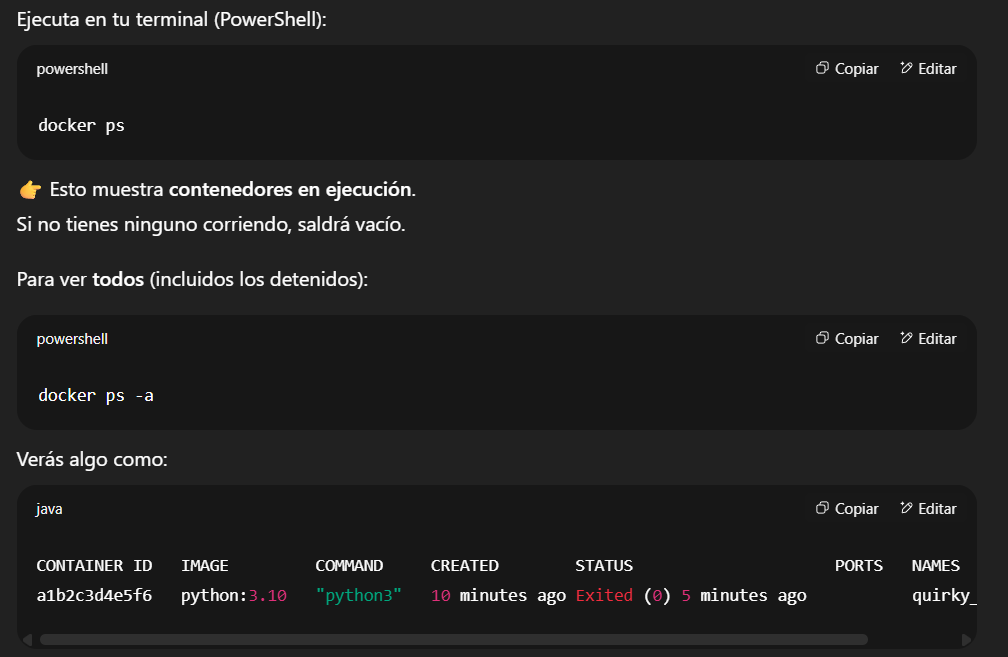

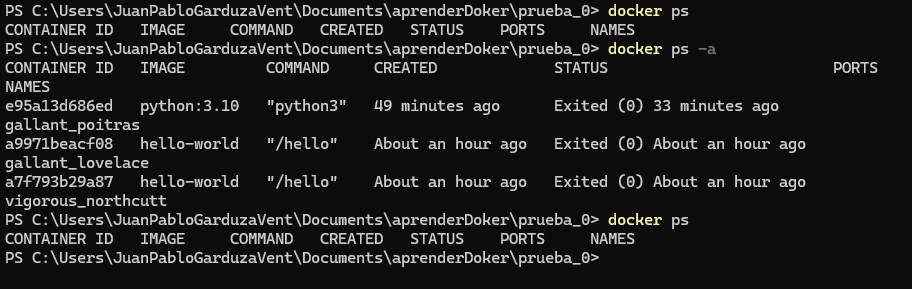

*DETENER*

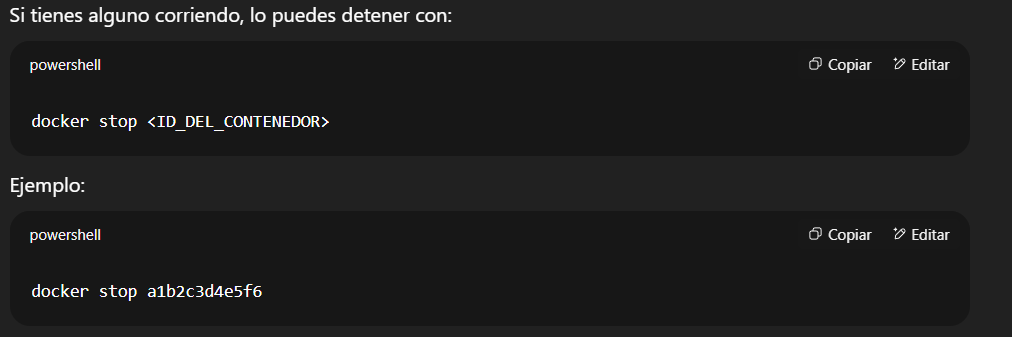

*ELIMINAR CONTENEDOR*

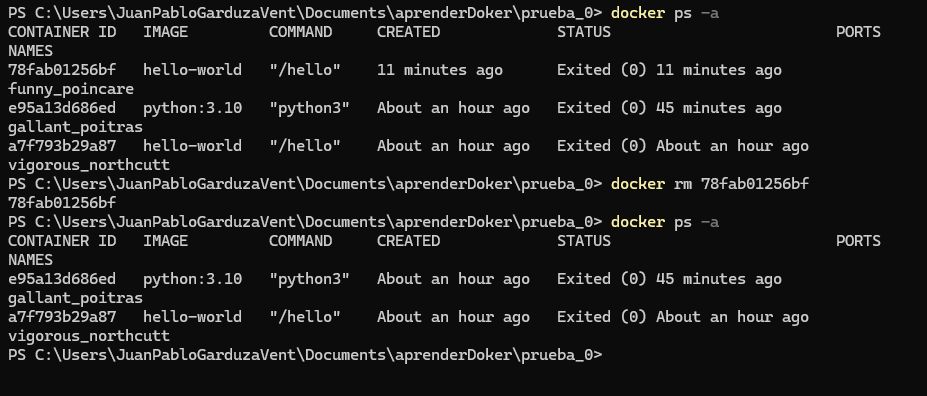

*ELIMINAR TODOS*

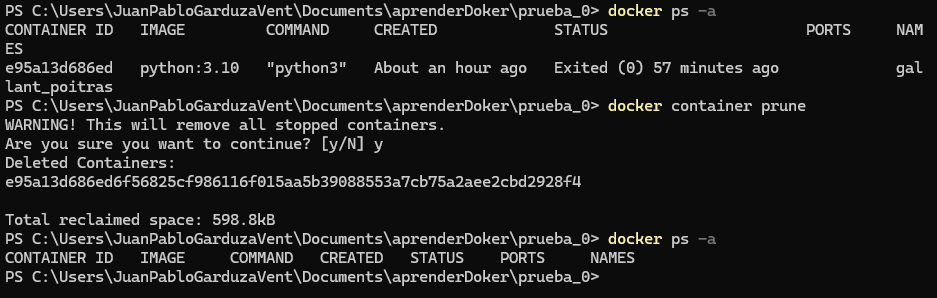

*Docker images*

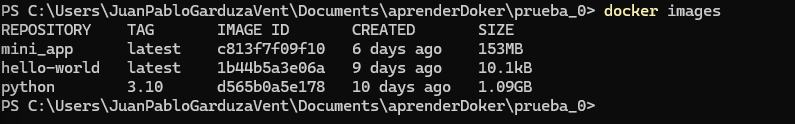

*ELIMINAR IMAGENES*

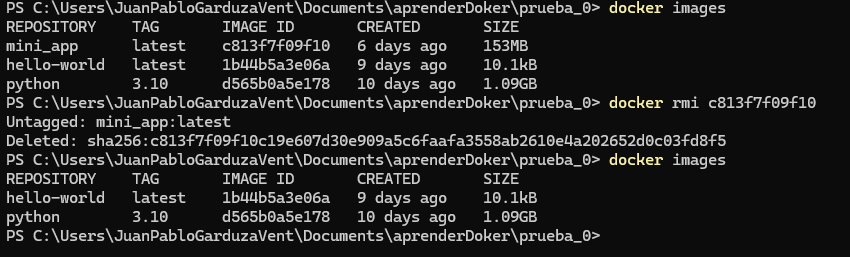

*ELIMINAR TODAS LAS IMAGENES*

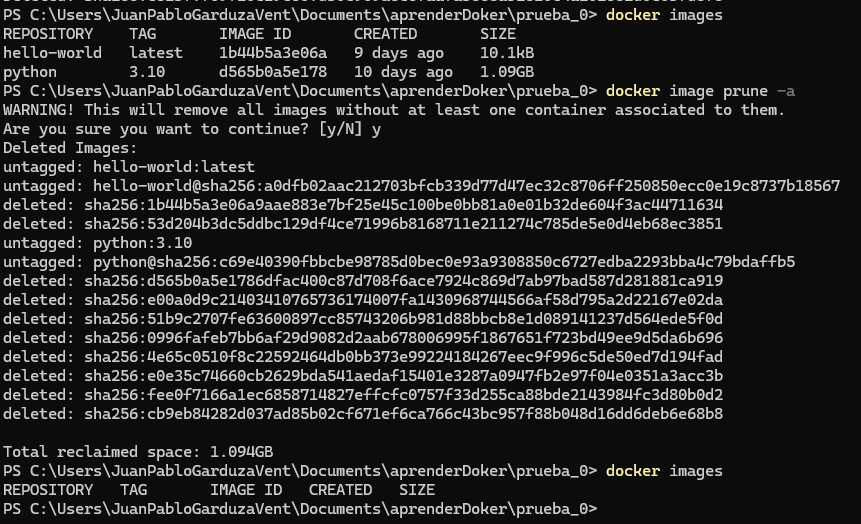

> DOCKER FILE

Es un archivo de texto (sin extencion, se llama Dockerfile) que contiene instrucciones para construir una imagen personalizada.

*Receta automatica:*

* Tú escribes los pasos.

* Docker los ejecuta uno por uno y genera una imagen.

* Luego, esa imagen la puedes ejecutar con docker run.

> *NOTAS* 

* Si deceas agregar un cambio al docker file, cuando ya se aplico el build y run, se deben reconstruir la imagen

* Esa imagen puede usarse para crear uno o varios contenedores

* Puedes tener Dockerfile.paso1, Dockerfile.paso2, etc (para usalros indicar cual):
    * docker build -t imagen_paso1 -f Dockerfile.paso1 .
    * docker build -t imagen_paso2 -f Dockerfile.paso2 .

* se puede heredar imagenes creadas a otro:
    * FROM -> From prubea2:1:0

* Estados de contenedor
    + running → está en ejecución.

    + exited → ya terminó su proceso (ejemplo: corriste python app.py y terminó).

    + paused → está "congelado", pero se puede reanudar.

    + dead → ya no se puede ni pausar ni reiniciar (raro, ocurre por errores graves).


> Ejemplos 

1. Base y mensaje inicial 

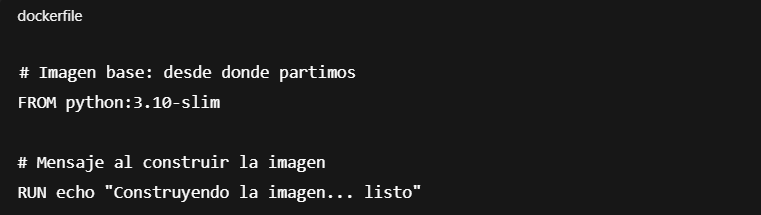

FROM → define la base de la imagen (Python 3.10 en este caso).

RUN echo ... → se ejecuta durante la construcción, el mensaje aparece en la terminal mientras haces docker build.

CMD → instrucción que se ejecuta cuando el contenedor arranca.


In [ ]:
# Imagen base: desde donde partimos
FROM python:3.10-slim

# Mensaje al construir la imagen
RUN echo "Construyendo la imagen... listo - RUN" 

#instrucción que se ejecuta cuando el contenedor arranca.
CMD ["echo", "Hola desde Docker -  CMD"]

*Prueba*

* docker build -t prueba1:1.0 .

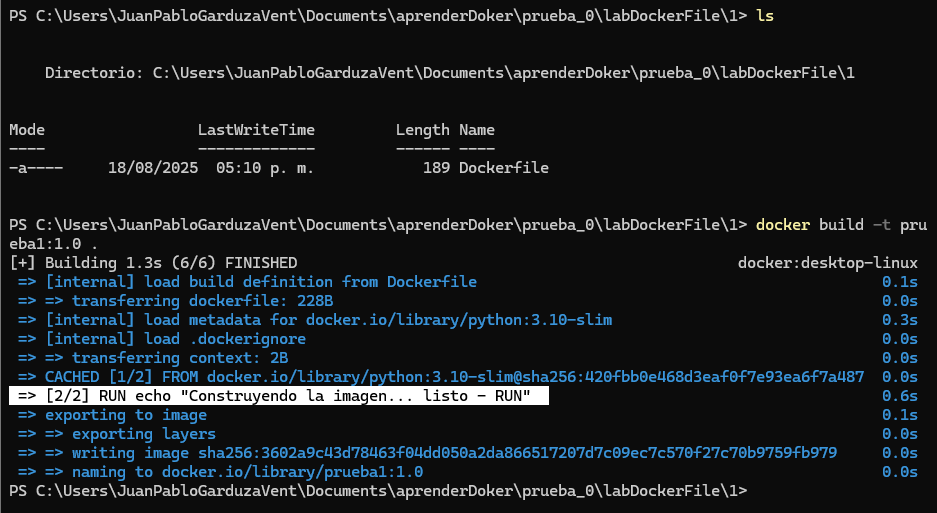

* docker run --rm prueba1:1.0

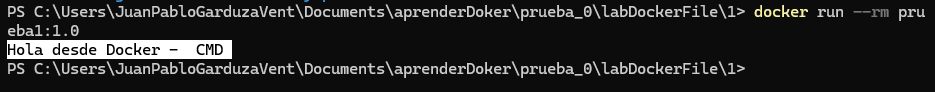

2. Crear directorios y archivos

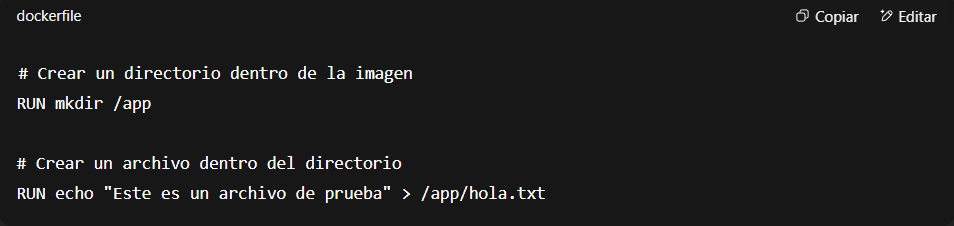



In [ ]:
# Imagen base (puede ser cualquier Linux ligero como Alpine o Debian)
# OBLIGATORIOOOO
FROM alpine:latest


# Crea un directorio dentro de la imagen
RUN mkdir /app

# Crea un archivo dentro del directorio
RUN echo "Esto es una archivo prueba" > /app/hola.txt


#soli se colocab muchos cmd, solo toma el ultimo
# Ejecuta varios comandos al iniciar el contenedor
CMD [ "sh", "-c", "ls /app && echo 'vamos a ver que trae el hola.txt' && cat /app/hola.txt" ]

*NOTA*

Usando un script sh:

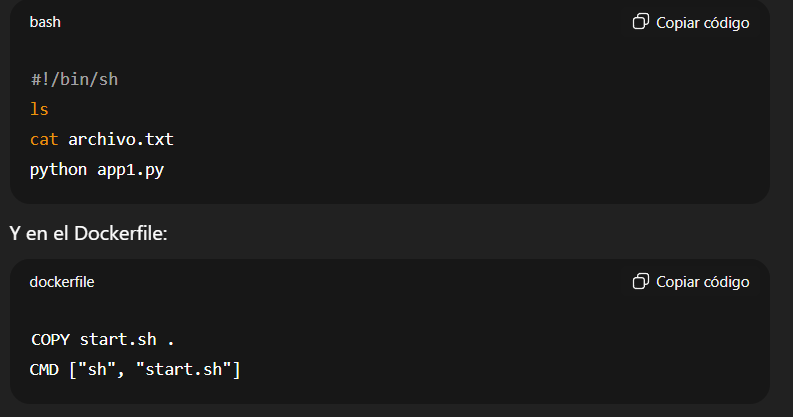

*LO QUE SUCEDE O LOS COMANDOS QUE SUCEDEN, SON DENTRO DEL CONTENEDOR, NO DE MANERA LOCAL*

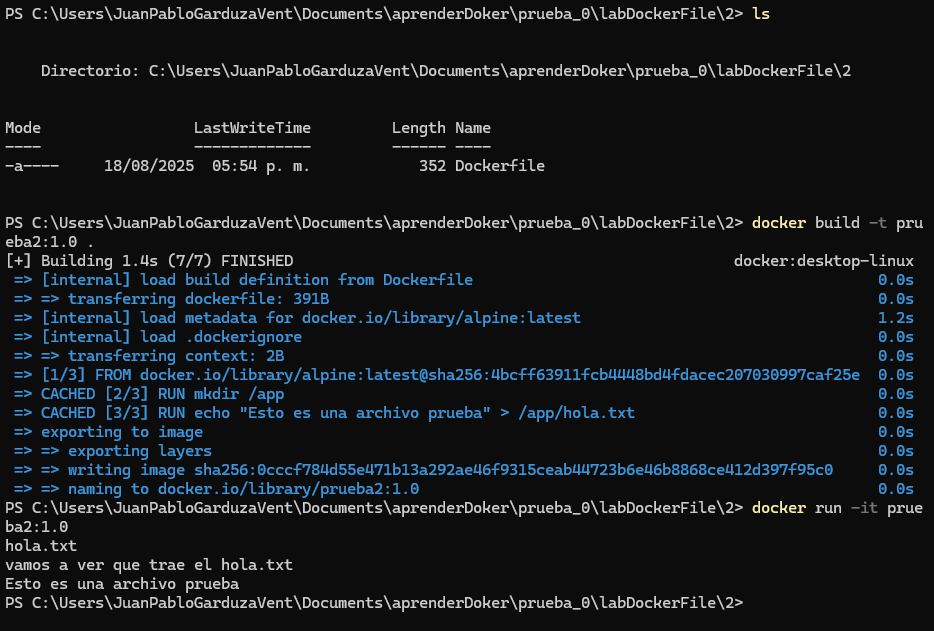

3. Copy


In [ ]:
FROM alpine:latest

# Crear directorio
RUN mkdir /app

############# EJEMPLO 3

# Copiar holaMundo.py al contenedor
COPY holaMundo.py /app/holaMundo.py

# Comando que se ejecuta al iniciar el contenedor
CMD ["sh","-c","ls /app && cat /app/holaMundo.py"]


Como vemos, se crea el dir, y copia a la vez el archivo al nuevo dir, al ejecutar checa los comandos ls y cat

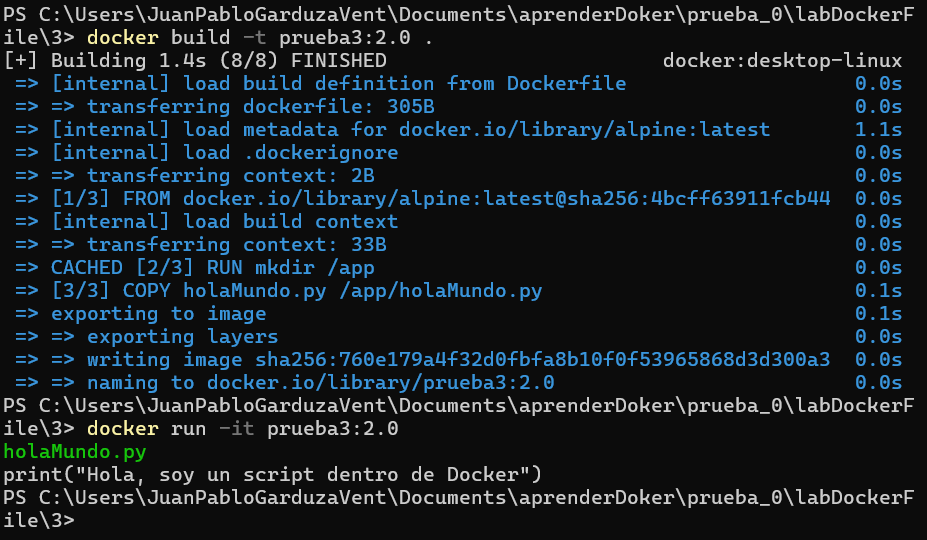

4. Herencia de imagen

In [ ]:
# En lugar de alpine, usa tu imagen ya creada
FROM prueba2:2.0  

# Ahora sí, construyes sobre lo que ya trae /app/hola.txt
COPY holaMundo.py /app/holaMundo.py

CMD ["sh", "-c", "ls /app && cat /app/holaMundo.py"]


Como vemos, tomamos imagen donde de ahi parte, mas no desde 0

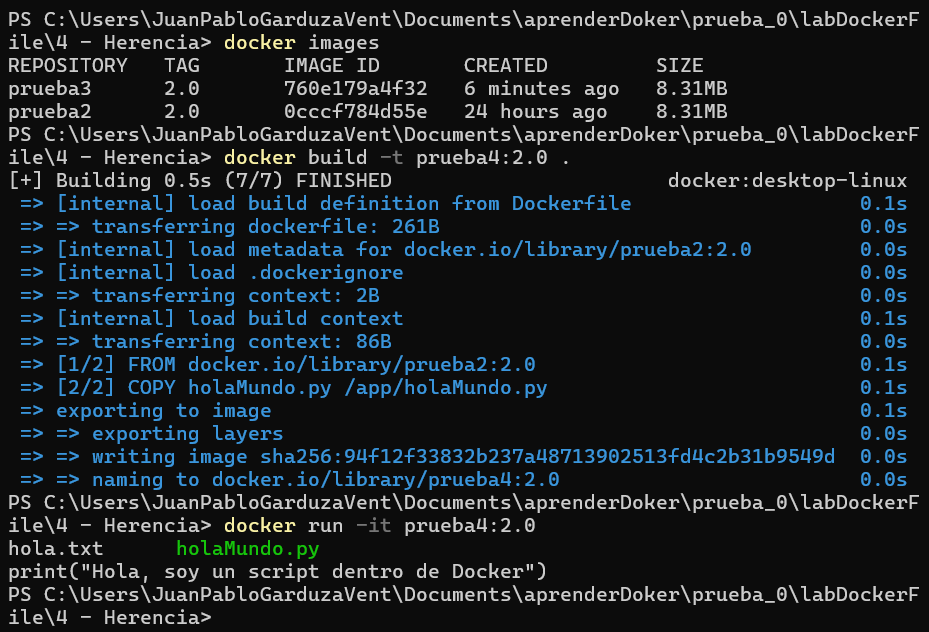

5. Entrar a contennedor 

a. 

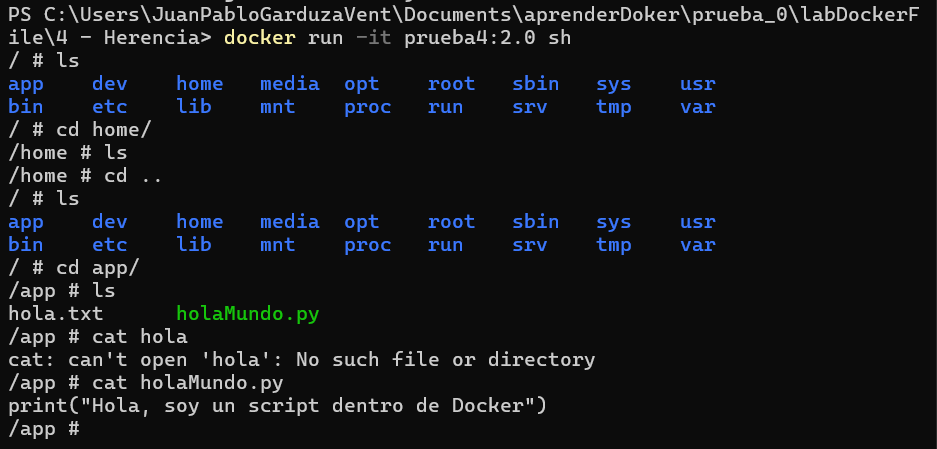

verificamos que este en ejecucion

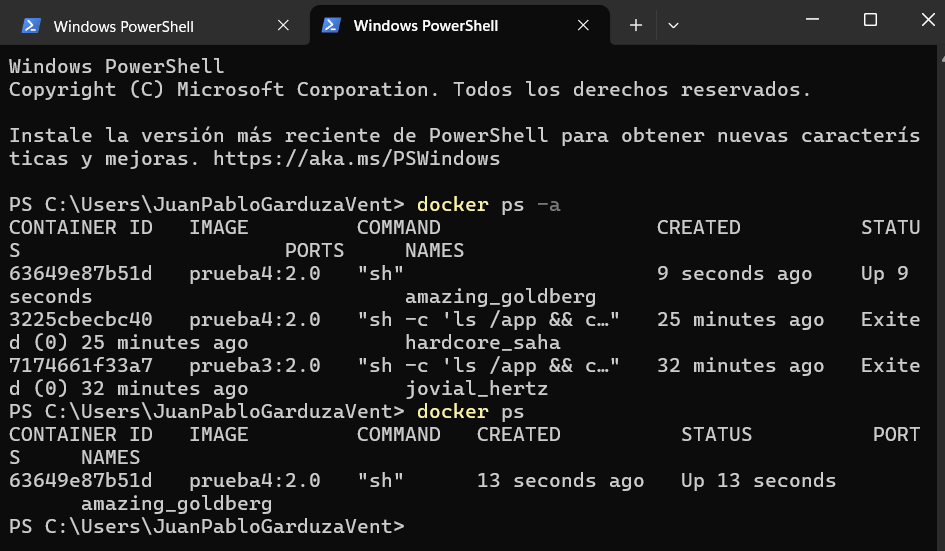

*NOTA*

* Cuando sales del contenedor (exit) y no lo guardaste, los cambios se pierden.

* Si quieres guardar cambios en una nueva imagen:
    * docker commit <container_id> prueba3_modificada:1.0
        * Ahora tienes una nueva imagen con los cambios que hiciste dentro del contenedor.



b. haces otro Dockerfile que parte de tu imagen existente y aplicas cambios:



In [ ]:
FROM prueba3:2.0

# Crear un nuevo directorio
RUN mkdir /app/nuevo_dir

# Agregar un nuevo script
COPY nuevo.py /app/nuevo_dir/nuevo.py

# CMD final
#CMD ["sh","-c","ls /app && ls /app/nuevo_dir && cat /app/nuevo.py"]
CMD ["sh","-c","ls /app && ls /app/nuevo_dir && cat /app/holaMundo.py"]


In [ ]:
#nuevo.py
print("Hola, soy un script dentro de Docker")

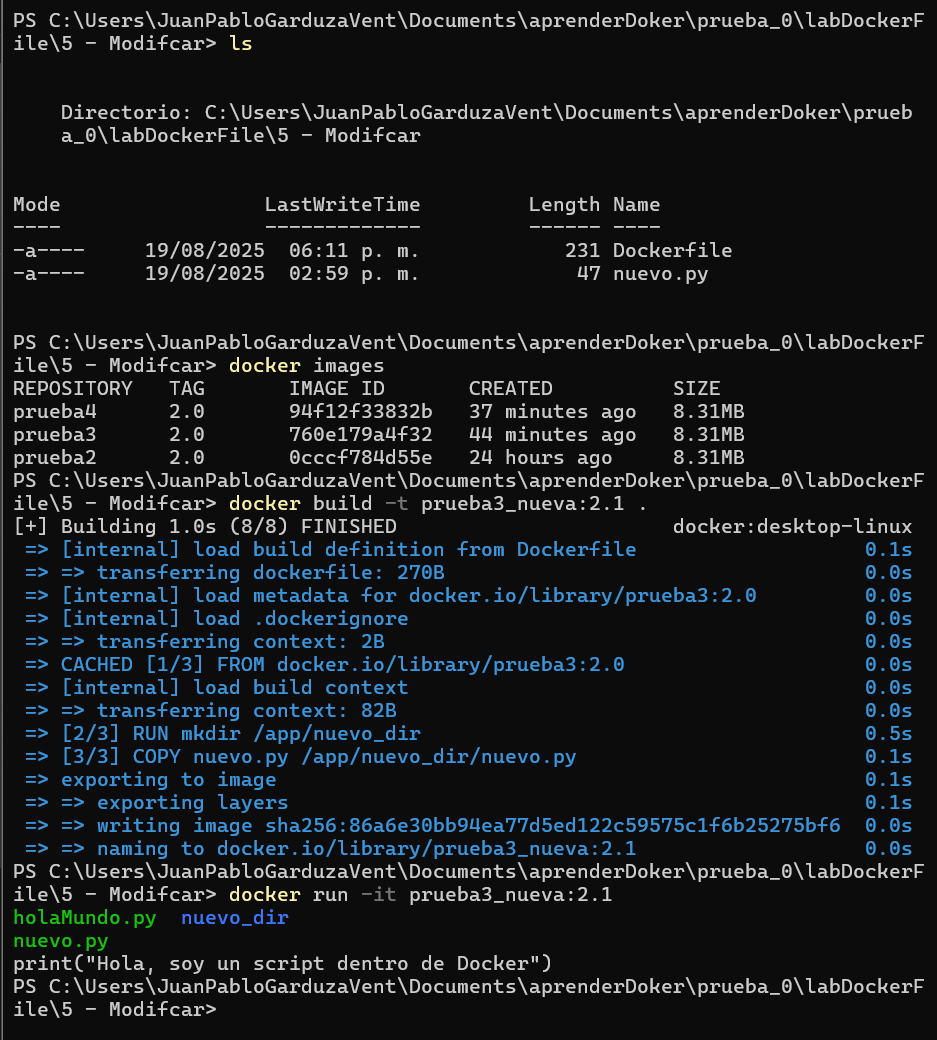

vemos 

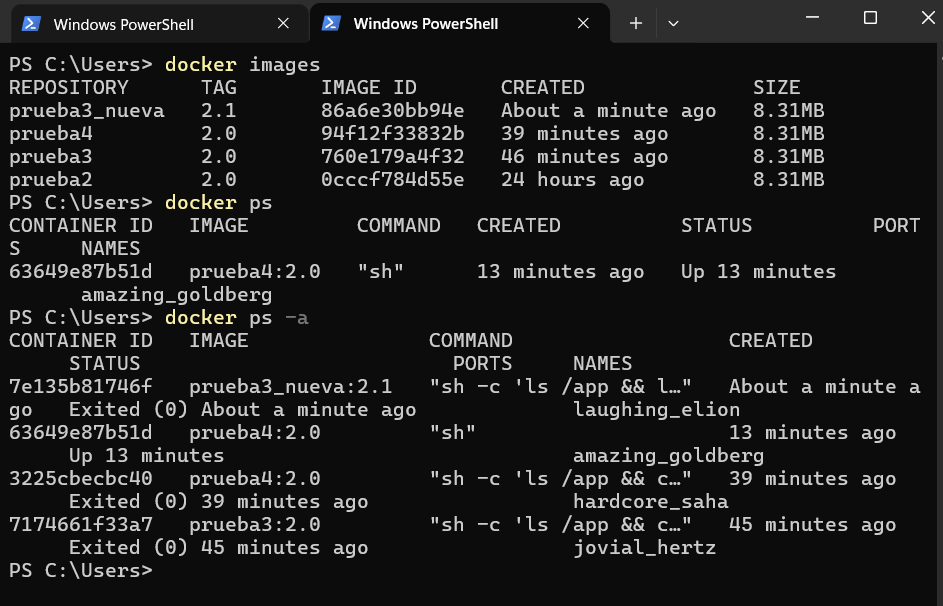

*NOTA GENERAL*

- docker run -it prueba3:1.0 sh
    - Lo que haces *solo afecta ese contenedor en vivo.*
    - Si creas archivos, modificas scripts o carpetas, los cambios existen mientras el contenedor esté vivo.
    - Si matas el contenedor (exit o docker stop), los cambios desaparecen, porque no modificaste la imagen original.
    - Si quieres guardar cambios en una nueva imagen: docker commit <container_id> prueba3_modificada:1.0
    - Luego puedes correr un nuevo contenedor a partir de esa imagen: docker run -it prueba3_modificada:1.0
- Con FROM en un Dockerfile
    - creas una nueva imagen heredando todo lo que ya tenía la imagen base. Es declarativo, reproducible y fácil de versionar.

*Forma 2*

In [ ]:
docker exec -it a4f8f0439588 sh

- Eso abre un shell dentro de un contenedor en ejecución.

- Pero ojo: si ya está terminado (Exited), tienes que levantarlo de nuevo con start

*Forma 3*

si el proceso esta muerto

> revivir proceso

In [ ]:
docker start -ai a4f8f0439588


- -a → attach (adjuntarte a la salida).

- -i → modo interactivo.

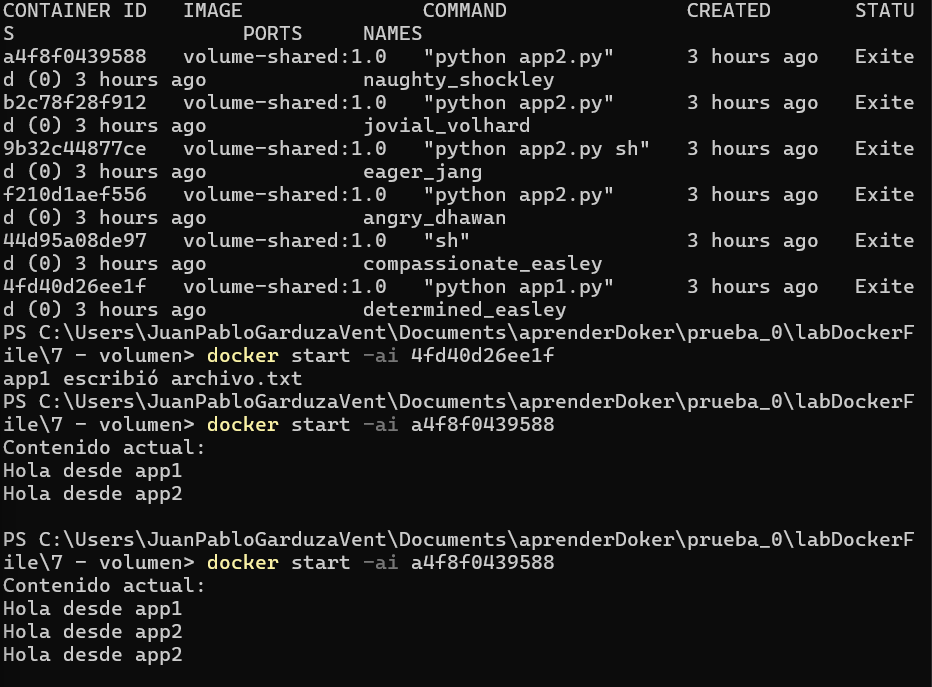

*Este ejemplo viene del ejemplo-7*

6. CMD

In [ ]:
FROM prueba3:2.0

RUN apk update && apk add --no-cache python3 py3-pip

CMD ["python3", "/app/holaMundo.py"]

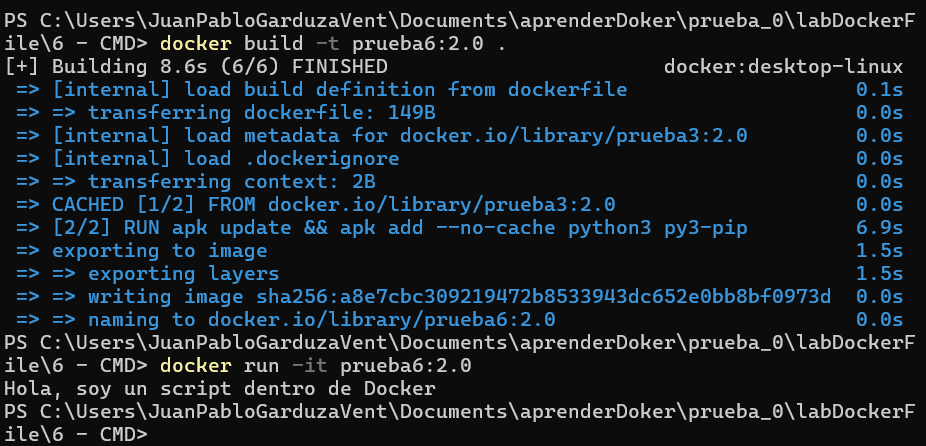

7. Volumenes

*Conceptos:*

* Espacio de almacenamiento persistente:
    * Es un directorio que Docker administra especialmente para que los datos no se pierdan cuando borras un contenedor.
    * Puede estar dentro del contenedor, pero Docker lo guarda fuera de la capa de la imagen, en un área especial de tu máquina.
* Tipos: 
    * Volumen anónimo
        * Persiste aunque borres el contenedor, pero no sabes exactamente dónde está en tu PC.
        * Docker crea un directorio en su almacenamiento interno (/var/lib/docker/volumes/...).
        * Útil si solo quieres que los datos sobrevivan a contenedores temporales.
    * Volumen mapeado a tu máquina (-v host_path:container_path)
        * Se mapea a una carpeta concreta en tu disco.
        * Ideal para desarrollo o intercambio de archivos entre contenedores y tu PC.
* Volúmenes y contenedores múltiples
    * Sí, dos contenedores pueden usar el mismo volumen.
    * Esto permite compartir datos entre contenedores (por ejemplo, dos apps accediendo a los mismos logs o bases de datos).

*Ejemplo*

docker-volume-lab/

│── app1.py

│── app2.py

│── Dockerfile

In [ ]:
# app1.py
with open("/app/data/archivo.txt", "w") as f:
    f.write("Hola desde app1\n")
print("app1 escribió archivo.txt")


In [ ]:
# app2.py
with open("/app/data/archivo.txt", "a") as f:
    f.write("Hola desde app2\n")
with open("/app/data/archivo.txt") as f:
    print("Contenido actual:")
    print(f.read())


Dockerfile:

In [ ]:
#carga python
FROM python:3.10-slim
#crea el dir, y a la vez se dice que todo se trabajara sobre el
WORKDIR /app
COPY app1.py .
COPY app2.py .
#crea un dir donde cuando ese ejcute el comando run
VOLUME ["/app/data"]
# se ejecuta solo y solo si, no hay mas argunemntos despues del run
CMD ["python", "app1.py"]

In [ ]:
#carga python
FROM python:3.10-slim
#Agrega esto a tu Dockerfile para instalar bash o sh
RUN apt-get update && apt-get install -y bash

#crea el dir, y a la vez se dice que todo se trabajara sobre el
WORKDIR /app
COPY app1.py .
COPY app2.py .
#crea un dir donde cuando ese ejcute el comando run
VOLUME ["/app/data"]
# se ejecuta solo y solo si, no hay mas argunemntos despues del run
CMD ["python", "app1.py"]

> WORKDIR : Crea el directorio si no existe, Cambia el contexto de ejecución a ese directorio.

Todo sera ahora ejecutado en workdir: /app

> VOLUME ["/app/data"] : Declara que /app/data es persistente dentro de la imagen. Docker lo gestiona internamente si no se mapea.

*EJECUCION*

1. construir imagen

In [ ]:
docker build -t volume-shared:1.0 .

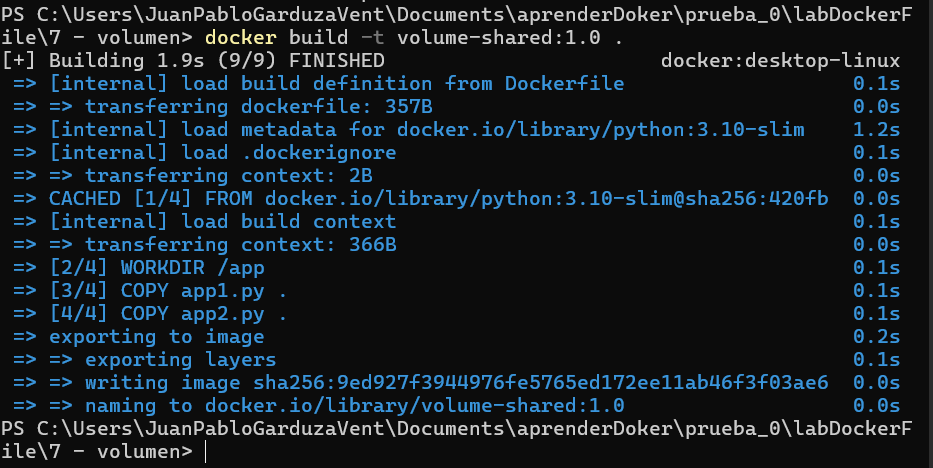

*Que sucede?*

- Se construye la imagen.

- No crea ningun volumen local aun.

- Solo registra que /app/data sera un volumen cuando *SE USE LA IMAGE*

2. Creamos un volumen externo (para saber donde esta)

Docker crea inmediatamente el volumen en tu máquina. Pero no lo verás como un directorio visible en tu sistema de archivos normal (como en tu carpeta de usuario).

- Tipicamente se guarda ahi:

    - */var/lib/docker/volumes/mi-volumen/_data*

Dentro de *_data es donde se guardan los archivos que el contendeor escriba en el volumen*

- Para inspeccionar el volumen:

    - *docker volume inspect mi-volumen*

In [ ]:
docker volume create mi-volumen

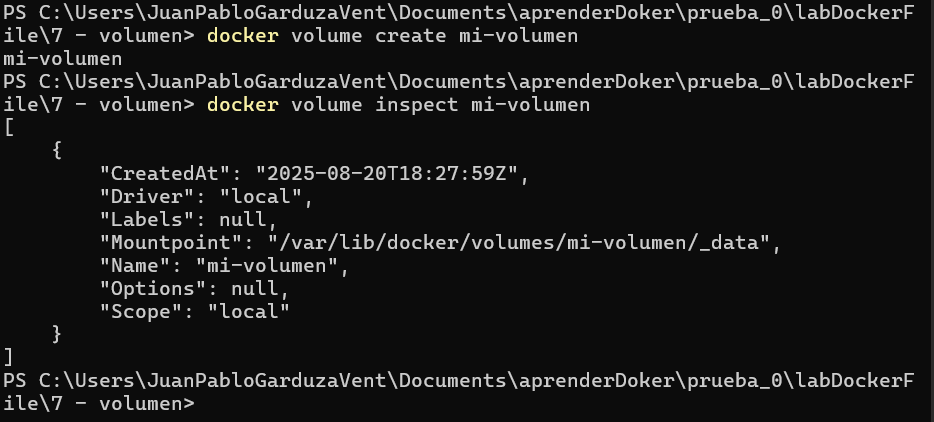

El volumen está listo para usarse, pero no contiene nada hasta que lo montas en un contenedor. Ejemplo:

*Que sucede?*

- Crea un volumen local en tu máquina Docker.
- Puedes usarlo luego al correr el contenedor.


3. Ejecutamos contenedor 1 - ejemplo:id(1001)

In [ ]:
docker run -v mi-volumen:/app/data volume-shared:1.0


Cuando se ejecuta:

*docker run -v /ruta/local:/app/data imagen*

- Crea el directorio /app/data dentro del contenedor si no existe (esto lo hace automáticamente).
- Enlaza ese directorio con el que tú especificaste localmente (/ruta/local), montándolo como un volumen.
- Todo lo que el contenedor escriba en /app/data se guarda directamente en tu máquina local, en /ruta/local.

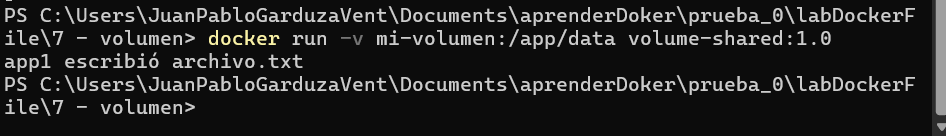

*Que sucedio?*

- Se ejecuta app1.py.

- Crea /app/data/archivo.txt con "Hola desde app1".




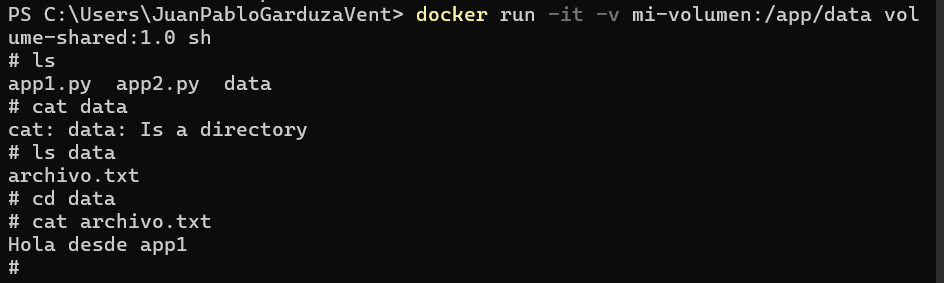

4. Ejecutamos un nuevo contenedor

In [ ]:
docker run -v mi-volumen:/app/data volume-shared:1.0 python app2.py

Al darle mas argumentos (con override) como "python app2.py"

Eliminara la sentencia CMD:

- CMD ["python", "app1.py"]

por lo que ejecutara app2.py

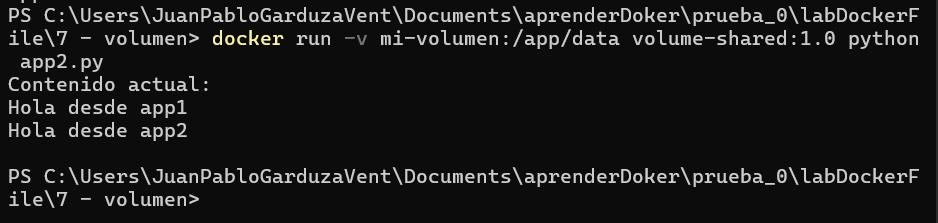

si observamos:

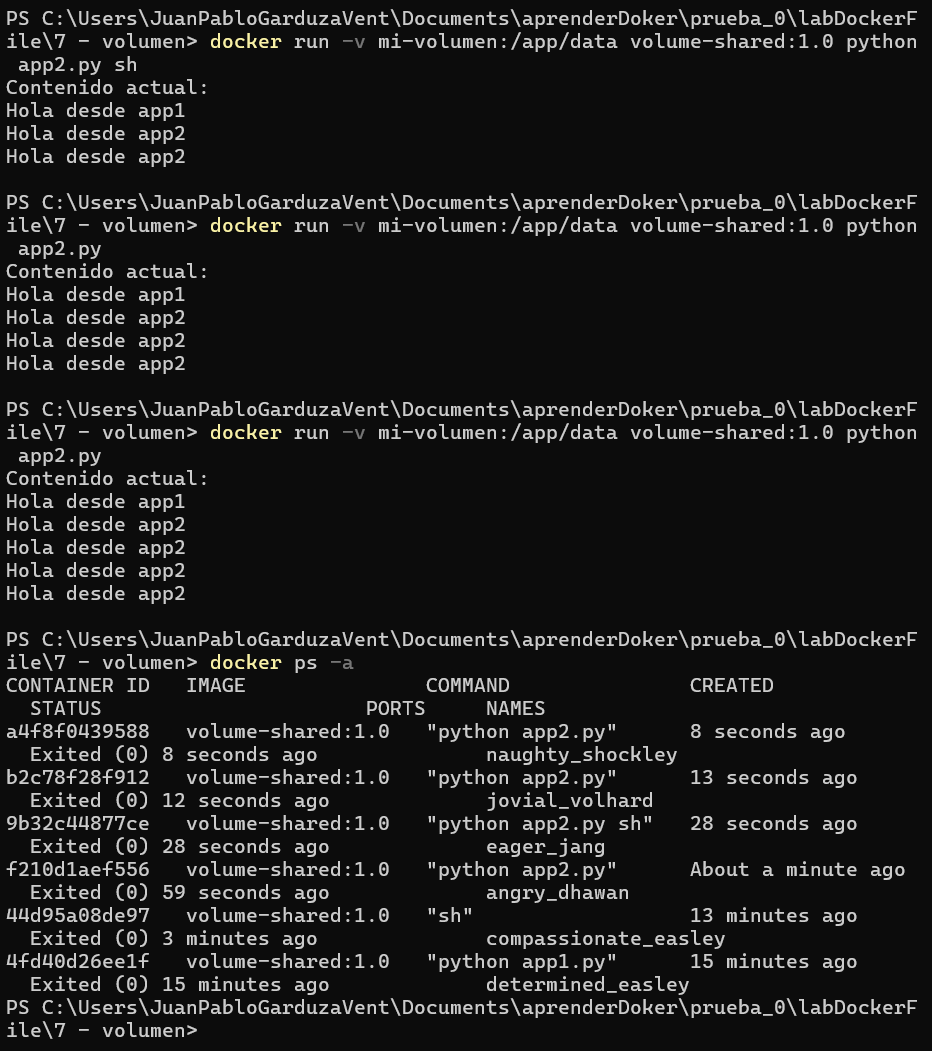

Cada nuevo contenedor usan ese volumen comparitdo y sobre escriben en el.

*Visual*



- Imagen
[ Imagen: volume-shared:1.0 ]
        |
        |  docker run
        v
+-------------------------+
| Contenedor A (ID: 123) |
+-------------------------+

Cada vez que haces docker run, se crea un contenedor nuevo a partir de la misma imagen.


- Sin volumen:
+-------------------------+
| Contenedor A            |
|   /app/data/archivo.txt |
+-------------------------+


- Con Volumen
+-------------------------+         +---------------------+
| Contenedor A (ID: 123) | <-----> | Volumen: mi-volumen |
|    /app/data           |         |   (host Docker)     |
+-------------------------+         +---------------------+

1. Si borras el contenedor A, el volumen sigue existiendo.

2. Si levantas otro contenedor B, puede conectarse al mismo volumen.

*Varios contenedores*

                 +---------------------+
                 | Volumen: mi-volumen |
                 +---------------------+
                      ^           ^
                      |           |
+---------------------+           +---------------------+
| Contenedor A (ID:123)          | Contenedor B (ID:456)|
|  /app/data/archivo.txt         |  /app/data/archivo.txt|
+--------------------------------+-----------------------+

1. Aquí, si Contenedor A escribe en archivo.txt,

2. Contenedor B puede leerlo (y viceversa).

*En el ejemplo:*

- Ambos contenedores se crean a partir de la misma imagen volume-shared:1.0.

- Al correr con volumen montado:

1. *docker run -v mi-volumen:/app/data volume-shared:1.0 python app1.py*
2. *docker run -v mi-volumen:/app/data volume-shared:1.0 python app2.py*


- app1.py puede escribir en /app/data/archivo.txt.

- app2.py puede leer/modificar ese mismo archivo en otro contenedor, porque ambos comparten mi-volumen.

> 8. Docker redes (compose)

Imagina que tienes dos oficinas en un mismo edificio:

- Oficina A: es el contador (app de Python).

- Oficina B: es la bóveda de números (base de datos).

Cada oficina tiene su propio cuarto aislado (contenedor).
Por defecto, si los dos se encierran y no tienen un pasillo que los conecte,
no pueden hablar entre sí.

Respuesta:

1. Servidor (server.py)

    - Corre en Python, escucha en un puerto (5000).

    - Responde "Hola, soy el servidor 🚀" cuando alguien le pregunta.

2. Cliente (client.py)

    - Intenta conectarse al servidor por nombre (http://server:5000).

    - Muestra la respuesta en consola.

3. Docker Compose

    - Define dos servicios: server y client.

    - Ambos estarán en la misma red.



*EJEMPLO*

Imagina un vecindario privado:

- Casa A → un servidor web (por ejemplo, una API).

- Casa B → un cliente que consulta esa API.

- Casa C → otro servicio (ej. un "logger" que escucha mensajes).

Todos están en la misma calle (la red interna de Docker Compose) y se pueden hablar por nombre:

- La Casa A se llama api

- La Casa B se llama client

- La Casa C se llama logger

*Estructura*

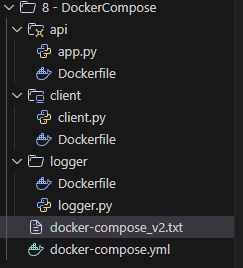

In [ ]:
# app.py

from flask import Flask
app = Flask(__name__)

@app.route("/")
def home():
    return "Hola desde la API!"

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000)


In [ ]:
#Dockerfile
FROM python:3.9
WORKDIR /app
COPY app.py .
RUN pip install flask
CMD ["python","-u", "app.py"]


In [ ]:
#client.py

import requests
import time
from datetime import datetime

while True:
    try:
        hora_envio = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        r = requests.get("http://api:5000/")
        hora_respuesta = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        print(f"[{hora_envio}] Enviado → [Cliente recibió]: {r.text} ← [{hora_respuesta}]")
    except Exception as e:
        hora_error = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        print(f"[{hora_error}] Esperando API... Error: {e}")
    time.sleep(3)


In [ ]:
#Dockerfile
FROM python:3.9
WORKDIR /app
COPY client.py .
RUN pip install requests datetime
CMD ["python", "-u","client.py"]


In [ ]:
#logger.py

import time

while True:
    print("Logger activo...")
    time.sleep(5)


In [ ]:
#Dockerfile

FROM python:3.9
WORKDIR /app
COPY logger.py .
CMD ["python","-u", "logger.py"]


Hay dos fomras de crear el *Docker-compose*

1. Aqui la red se crea automaticamente

In [ ]:
#v1
version: "3.9"
services:
  api:
    build: ./api
    container_name: api_service
    ports:
      - "5000:5000" #puerto maquina local : puerto dentro del contenedor

  client:
    build: ./client
    container_name: client_service
    depends_on:
      - api

  logger:
    build: ./logger
    container_name: logger_service

2. Aqui se crea manaul


In [ ]:
version: "3.9"

services:
  api:
    build: ./api
    container_name: api_service
    ports:
      - "5000:5000"
    networks:
      - red_principal

  client:
    build: ./client
    container_name: client_service
    depends_on:
      - api
    networks:
      - red_principal

  logger:
    build: ./logger
    container_name: logger_service
    networks:
      - red_principal

networks:
  red_principal:
    driver: bridge

*Ejecutamos*

In [ ]:
docker-compose up --build


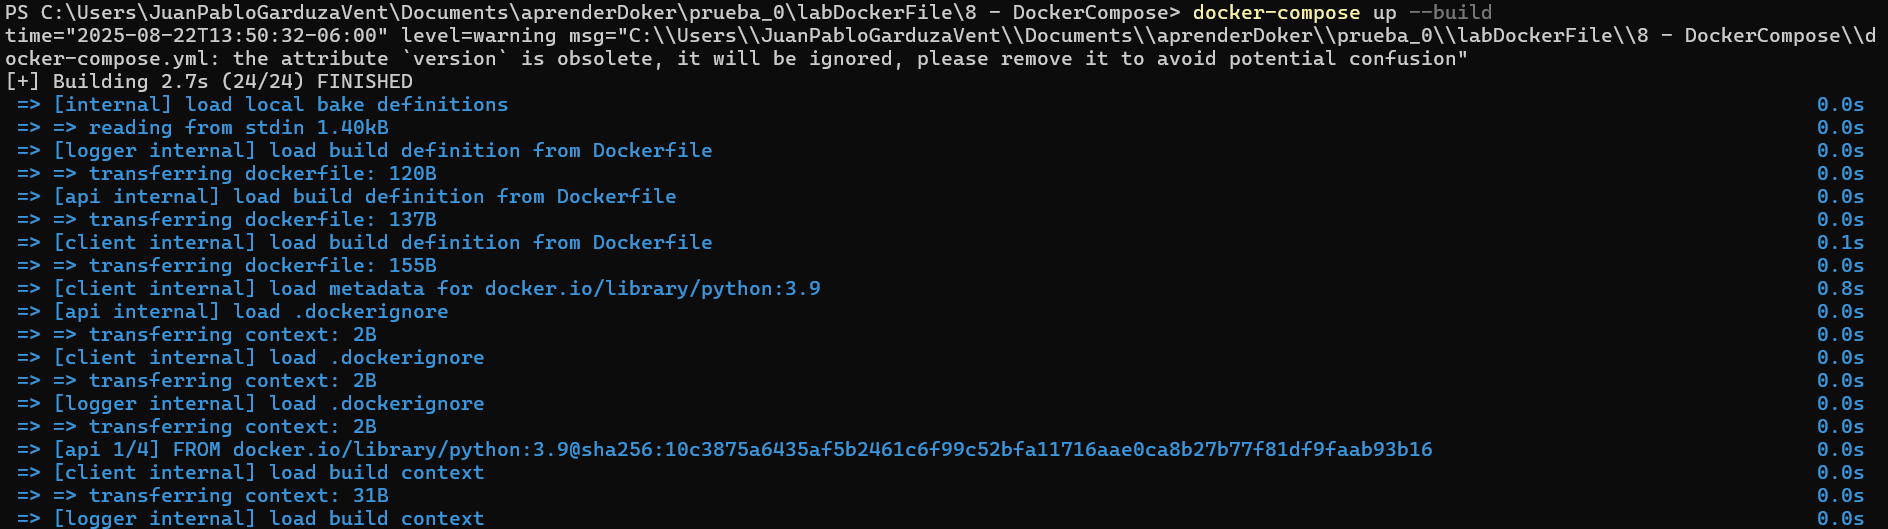

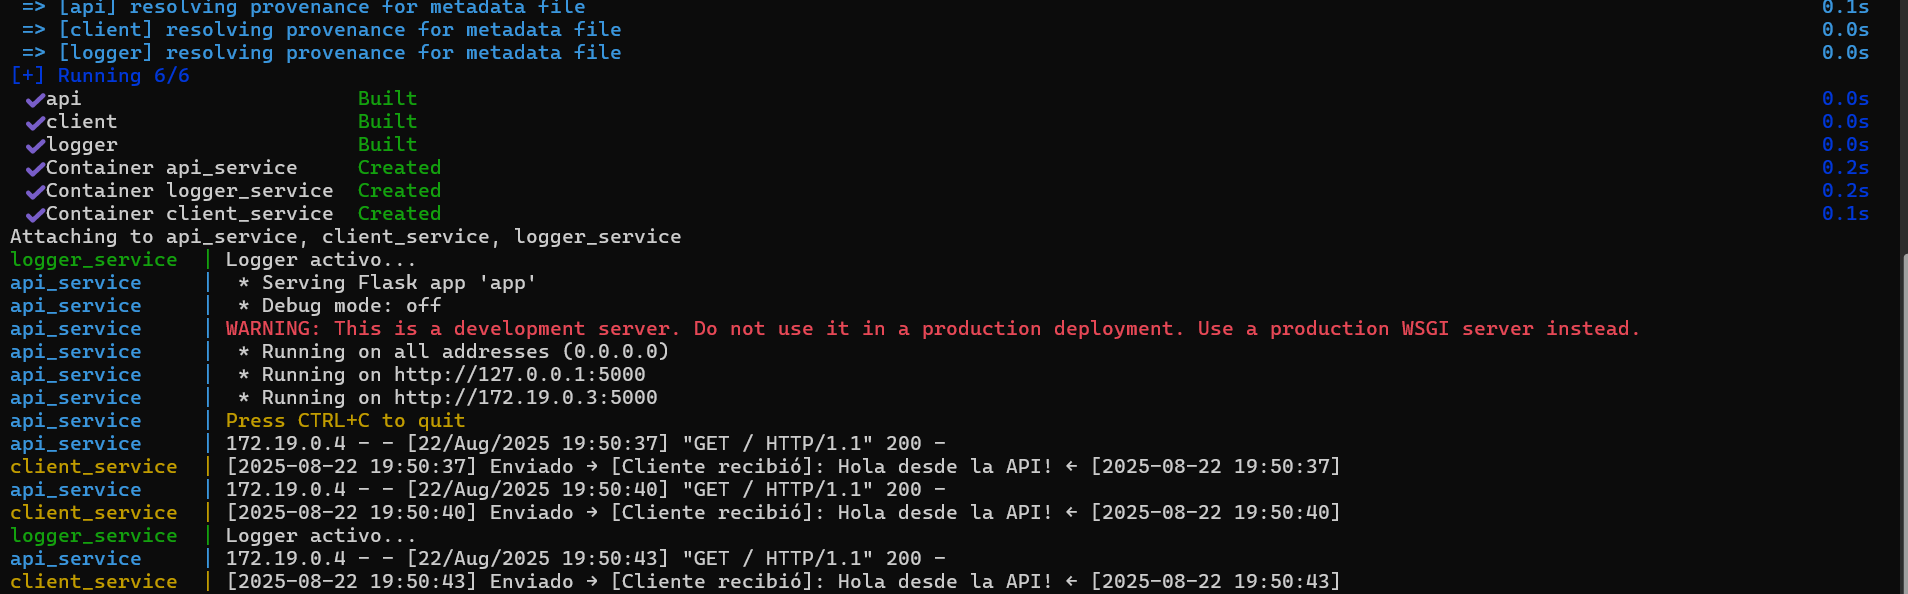

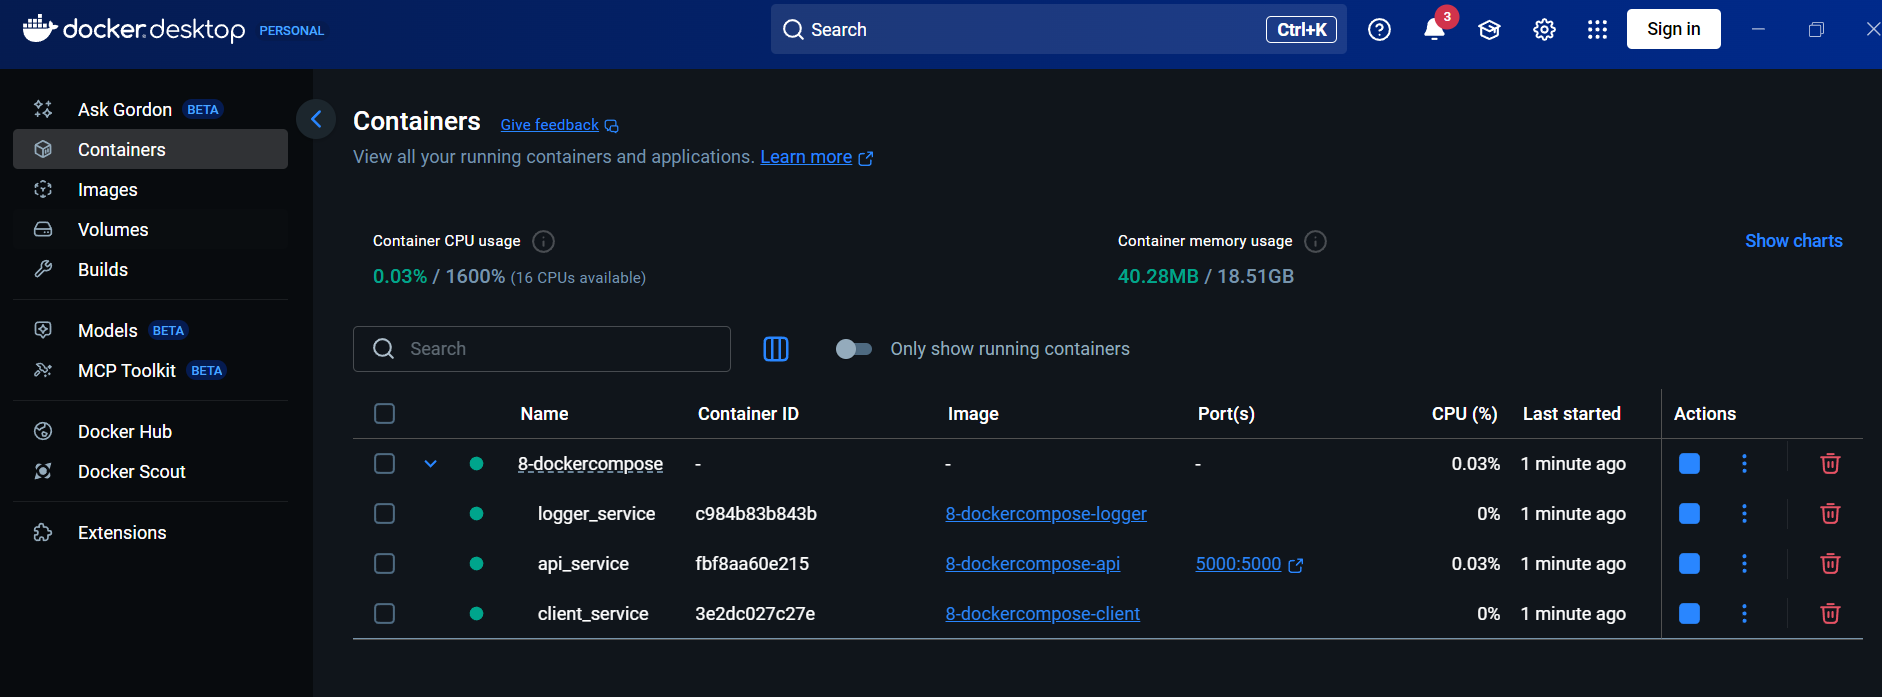

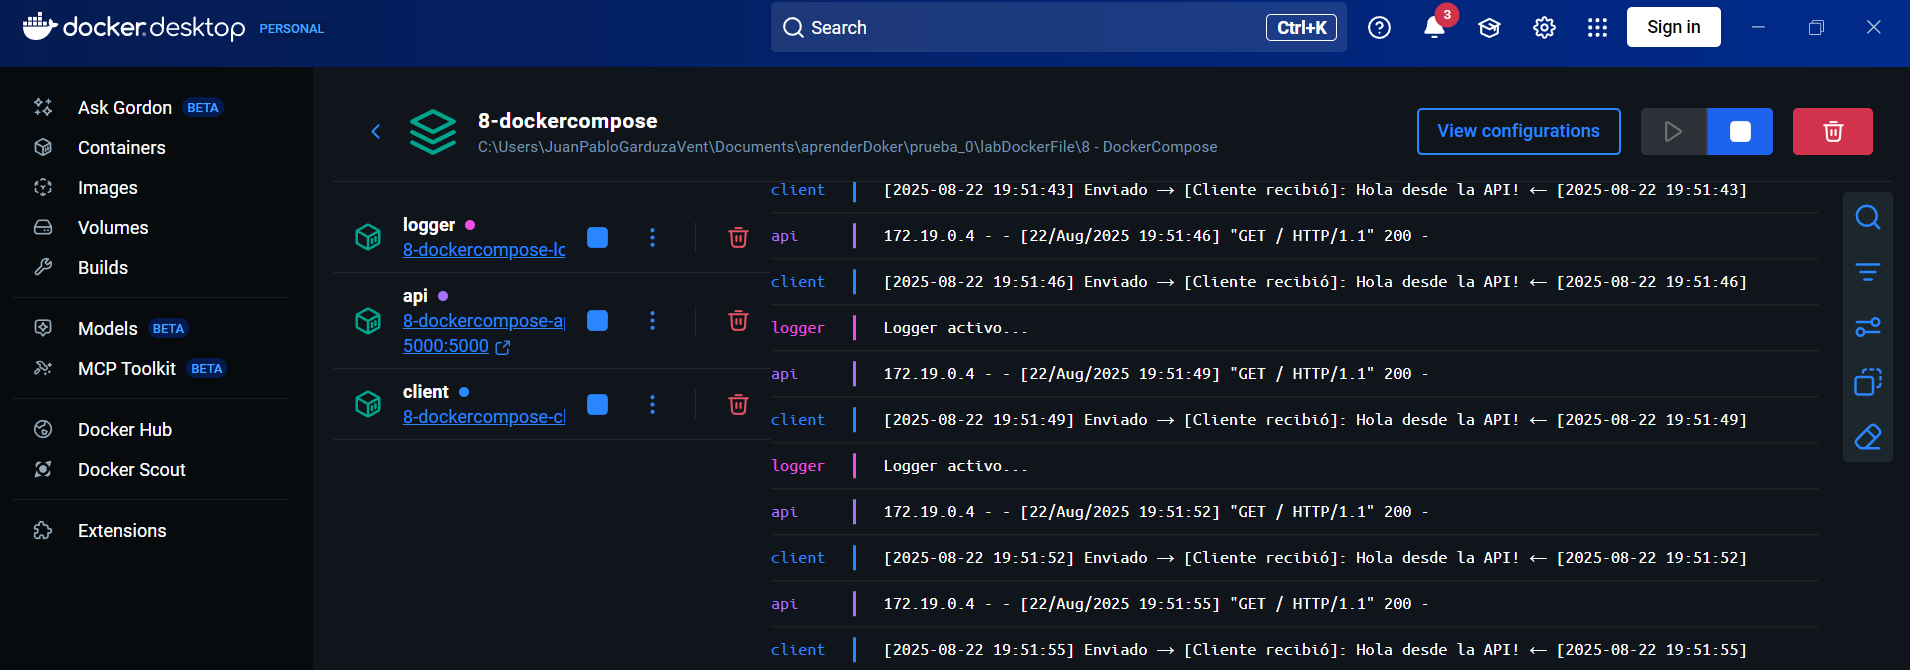

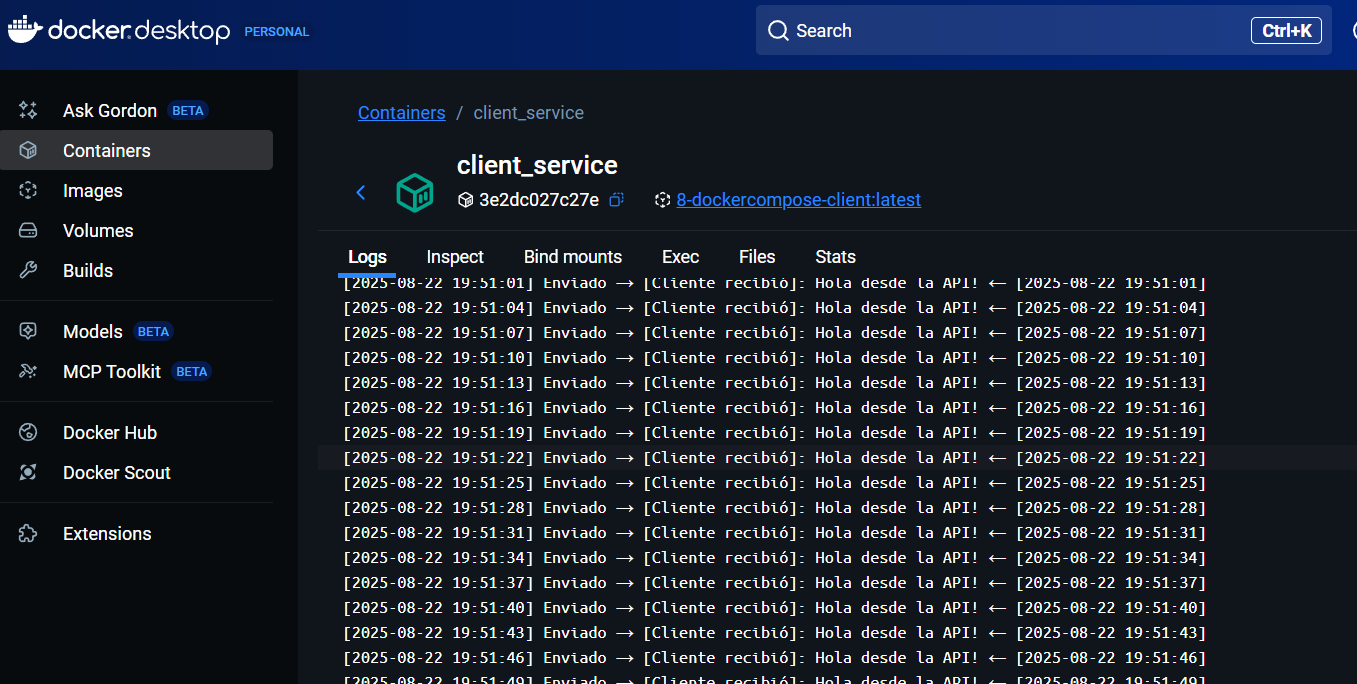

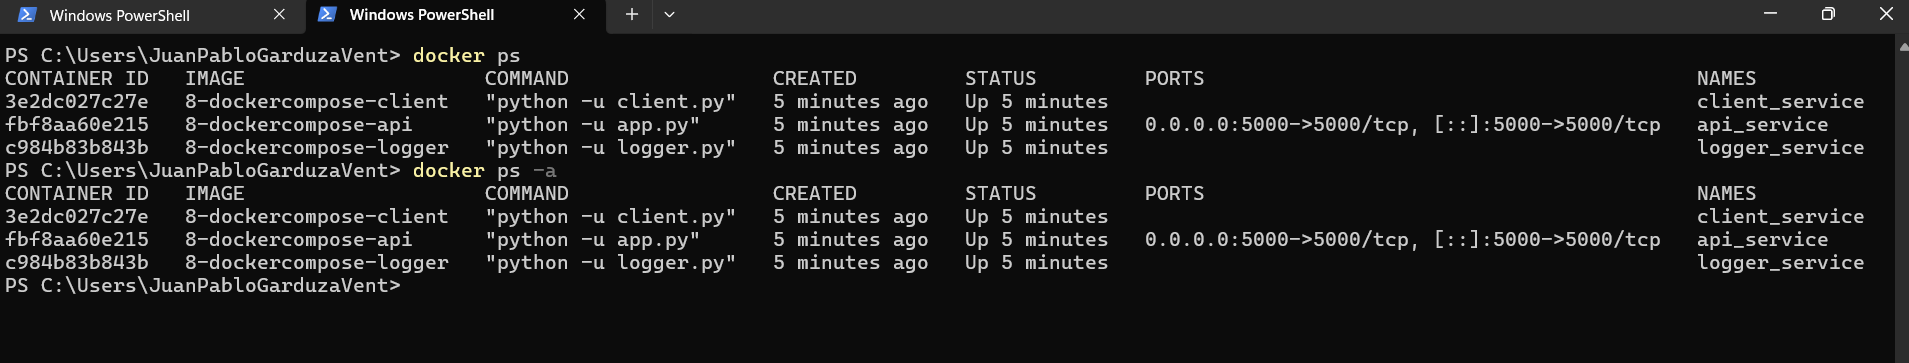

*Que pasa si muere un contenedor? mueren todos los contenendores?*

Respuesta corta: No necesariamente.
- Cada contenedor es independiente.
- Por defecto, si un contenedor muere, los demás siguen vivos.

*Nota*

- Cada contenedor en Docker tiene un ID único que identifica la instancia.

- Cuando muere y se reinicia con restart, Docker crea una nueva instancia con nuevo ID, aunque mantenga el mismo nombre de contenedor si lo definiste en Compose


*¿Cómo se reinicia un contenedor?*

1. Manual

In [ ]:
docker-compose restart nombre_servicio

- Reinicia solo ese servicio.

- Ejemplo: docker-compose restart api

2. Automatico 

In [ ]:
services:
  api:
    build: ./api
    restart: unless-stopped  # siempre reinicia si falla

*Nota*

Viene con las siguientes opciones:

- no → nunca reinicia (default)

- always → siempre intenta reiniciar

- on-failure → solo si termina con error

- unless-stopped → reinicia salvo que lo hayas parado manualmente

*Si sigue fallando por error de código (actualizar image)*

- Si el contenedor sigue fallando después de reinicios, significa que el problema está en tu código o configuración.

- Entonces tienes que arreglar el código (por ejemplo, el Flask API).

Opciones:

1. Reconstruir solo ese servicio:

In [ ]:
docker-compose up --build api

- Solo reconstruye y levanta la API.

- Los demás contenedores no se tocan, siguen en la misma red.

2. Levantar todo el Compose completo

In [ ]:
docker-compose up --build

- Reconstruye y levanta todos los servicios.

- Útil si hay cambios que afectan a varios contenedores.

*Agregar un contenedor nuevo a la red de Compose*

1. Si quieres que se comunique con los otros contenedores de Compose:

- Debes conectarla explícitamente a la misma red que Compose creó.

- Compose crea una red por proyecto (<nombre_carpeta>_default).

Comando:



In [ ]:
docker network connect mi-compose_default nuevo_contenedor

Ahora puede hablar con los demás usando los nombres de servicio de Compose.

2. Si quieres integrarla en el Compose formalmente:

- Lo correcto es agregarla al docker-compose.yml:


In [ ]:
servicios:
  nueva_app:
    build: ./nueva_app




Luego levantas todo:


In [ ]:

docker-compose up -d




Automáticamente estará en la red de Compose y tendrá nombre para que los demás la vean.

> EJEMPLO 2 - DockerCompose - dependencia

*Problematica*

6 contenedores en total:

- Contenedores independientes (no dependen de otros)

    - C1: usa id, nombre → valida el cliente.

    - C2: usa producto, precio, descuento → calcula precio final.

    - C3: usa categoria, stock → verifica inventario.

- Contenedores dependientes (usan resultados de los anteriores):

    - C4: recibe datos procesados de C1 → genera un token de validación.

    - C5: recibe datos procesados de C2 → genera un ticket de venta.

    - C6: recibe datos de C3, C4, C5 → arma el resultado final (ejemplo: "Venta aprobada con ID: 123 y ticket: X").

- Regla de ejecución:

Cada contenedor al terminar debe devolver "OK" (aunque su lógica sea trivial).

El último (C6) devuelve el producto final.

*Ejemplo de entrada*

In [ ]:
{
  "id": 123,
  "nombre": "Juan",
  "edad": 30,
  "producto": "Laptop",
  "precio": 1200,
  "descuento": 10,
  "categoria": "Electrónica",
  "stock": 5,
  "pais": "MX",
  "moneda": "USD"
}

*Creamos los servios web*

*s1_customer*

al hacer una peticion en *S1 = "http://s1_customer:8000/process"* vemos que la "IP" no es un localhost, no es un 127.0.0.1.

Si no hacer referencia a *s1_customer:8000* , esto hace referencia desde que se crea el Docker-compose:

s1_customer:

    build: ./s1_customer

    container_name: s1_customer

    healthcheck: #Le estás diciendo a Docker Compose que revise si el contenedor está listo para usarse.

      test: ["CMD", "curl", "-fsS", "http://localhost:8000/health"]

      interval: 5s

      timeout: 2s

      retries: 20

      start_period: 5s

Le estamos diciendo *s1_customer* es el nombre del contenedor, pero el contendedor se ejecuta desde local (ciertamente es localhost, pero con el nombre del contenedor (haciendo referencia a su local)), el puerto :

ports:

      - "8080:8000"

es declarado al final despues de crear todos lo contenedores, donde ese puerto lo usaran todos los contendedores pero cada contenedor tiene su propio nombre para su referencia (claro, se puede poner un puerto diferente para cada uno si es necesario)

In [ ]:
from flask import Flask, request, jsonify

app = Flask(__name__)

@app.get("/health")
def health():
    return jsonify(status="OK"), 200

@app.post("/process")
def process():
    data = request.get_json(force=True)
    result = {
        "id": data.get("id"),
        "nombre": data.get("nombre"),
        "valid": bool(data.get("id")) and bool(data.get("nombre"))
    }
    return jsonify(status="OK", data=result), 200

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8000)


*DockerFile*

- Run:
    - apt-get update → actualiza la lista de paquetes del sistema Debian.

    - apt-get install curl → instala curl, necesario para los healthchecks.

    - --no-install-recommends → evita instalar cosas que no necesitas.

    - rm -rf /var/lib/apt/lists/* → limpia archivos temporales para mantener la imagen ligera

In [ ]:
FROM python:3.11-slim
WORKDIR /app
RUN apt-get update && apt-get install -y --no-install-recommends curl \
    && rm -rf /var/lib/apt/lists/*
COPY app.py .
#--no-cache-dir evita guardar archivos temporales de instalación → imagen más ligera
RUN pip install --no-cache-dir flask requests 
EXPOSE 8000
CMD ["python", "app.py"]


*s2_pricing*

In [ ]:
from flask import Flask, request, jsonify

app = Flask(__name__)

@app.get("/health")
def health():
    return jsonify(status="OK"), 200

@app.post("/process")
def process():
    data = request.get_json(force=True)
    precio = float(data.get("precio", 0))
    descuento = float(data.get("descuento", 0))
    final_price = round(precio * (1 - descuento/100.0), 2)
    result = {
        "id": data.get("id"),
        "final_price": final_price,
        "moneda": data.get("moneda", "USD")
    }
    return jsonify(status="OK", data=result), 200

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8000)


*DockerFile*

In [ ]:
FROM python:3.11-slim
WORKDIR /app
RUN apt-get update && apt-get install -y --no-install-recommends curl \
    && rm -rf /var/lib/apt/lists/*
COPY app.py .
#--no-cache-dir evita guardar archivos temporales de instalación → imagen más ligera
RUN pip install --no-cache-dir flask requests 
EXPOSE 8000
CMD ["python", "app.py"]

*s3_inventory*

In [ ]:
from flask import Flask, request, jsonify

app = Flask(__name__)

@app.get("/health")
def health():
    return jsonify(status="OK"), 200

@app.post("/process")
def process():
    data = request.get_json(force=True)
    stock = int(data.get("stock", 0))
    result = {
        "id": data.get("id"),
        "in_stock": stock > 0,
        "stock": stock
    }
    return jsonify(status="OK", data=result), 200

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8000)


*DockerFile*

In [ ]:
FROM python:3.11-slim
WORKDIR /app
RUN apt-get update && apt-get install -y --no-install-recommends curl \
    && rm -rf /var/lib/apt/lists/*
COPY app.py .
#--no-cache-dir evita guardar archivos temporales de instalación → imagen más ligera
RUN pip install --no-cache-dir flask requests 
EXPOSE 8000
CMD ["python", "app.py"]

*s4_token*

In [ ]:
from flask import Flask, request, jsonify
import time

app = Flask(__name__)

@app.get("/health")
def health():
    return jsonify(status="OK"), 200

@app.post("/process")
def process():
    data = request.get_json(force=True)  # espera {id, valid, nombre}
    valid = bool(data.get("valid"))
    token = f"TOKEN-{data.get('id')}-{int(time.time())%100000}" if valid else None
    result = {
        "id": data.get("id"),
        "valid": valid,
        "token": token
    }
    return jsonify(status="OK", data=result), 200

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8000)


*DockerFile*

In [ ]:
FROM python:3.11-slim
WORKDIR /app
RUN apt-get update && apt-get install -y --no-install-recommends curl \
    && rm -rf /var/lib/apt/lists/*
COPY app.py .
#--no-cache-dir evita guardar archivos temporales de instalación → imagen más ligera
RUN pip install --no-cache-dir flask requests 
EXPOSE 8000
CMD ["python", "app.py"]

*s5_ticket*

In [ ]:
from flask import Flask, request, jsonify

app = Flask(__name__)

@app.get("/health")
def health():
    return jsonify(status="OK"), 200

@app.post("/process")
def process():
    data = request.get_json(force=True)  # espera {id, final_price, moneda}
    id_ = data.get("id")
    final_price = data.get("final_price")
    ticket = f"TICKET-{id_}-{str(final_price).replace('.', '')}"
    result = {
        "id": id_,
        "ticket": ticket,
        "amount": final_price,
        "moneda": data.get("moneda", "USD")
    }
    return jsonify(status="OK", data=result), 200

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8000)


*DockerFile*

In [ ]:
FROM python:3.11-slim
WORKDIR /app
RUN apt-get update && apt-get install -y --no-install-recommends curl \
    && rm -rf /var/lib/apt/lists/*
COPY app.py .
#--no-cache-dir evita guardar archivos temporales de instalación → imagen más ligera
RUN pip install --no-cache-dir flask requests 
EXPOSE 8000
CMD ["python", "app.py"]

*s6_orchestrator* (llama a todos y arma el final)

Como se ve, al declarar los servicios dependiendientes, se ve que hace llamado al nombre del contenedor:

S1 = "http://s1_customer:8000/process"

S2 = "http://s2_pricing:8000/process"

S3 = "http://s3_inventory:8000/process"

S4 = "http://s4_token:8000/process"

S5 = "http://s5_ticket:8000/process"
    




In [ ]:
from flask import Flask, request, jsonify
import requests

app = Flask(__name__)



S1 = "http://s1_customer:8000/process"
S2 = "http://s2_pricing:8000/process"
S3 = "http://s3_inventory:8000/process"
S4 = "http://s4_token:8000/process"
S5 = "http://s5_ticket:8000/process"

@app.get("/health")
def health():
    return jsonify(status="OK"), 200

@app.post("/run")
def run_pipeline():
    master = request.get_json(force=True)

    # 1) Servicios base
    r1 = requests.post(S1, json=master).json()   # -> {status, data:{id,nombre,valid}}
    r2 = requests.post(S2, json=master).json()   # -> {status, data:{id,final_price,moneda}}
    r3 = requests.post(S3, json=master).json()   # -> {status, data:{id,in_stock,stock}}

    # 2) Dependientes
    r4 = requests.post(S4, json=r1["data"]).json()  # -> {data:{id,valid,token}}
    r5 = requests.post(S5, json=r2["data"]).json()  # -> {data:{id,ticket,amount,moneda}}

    # 3) Ensamble final
    final = {
        "id": master.get("id"),
        "valid": r4["data"]["valid"],
        "token": r4["data"]["token"],
        "final_price": r2["data"]["final_price"],
        "moneda": r2["data"]["moneda"],
        "in_stock": r3["data"]["in_stock"],
        "ticket": r5["data"]["ticket"],
        "stock": r3["data"]["stock"],
        "message": "Venta aprobada"
                   if (r4["data"]["valid"] and r3["data"]["in_stock"])
                   else "Venta pendiente o rechazada"
    }
    return jsonify(status="OK", result=final, steps={
        "s1_customer": r1,
        "s2_pricing": r2,
        "s3_inventory": r3,
        "s4_token": r4,
        "s5_ticket": r5
    }), 200

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=8000)


*DockerFile*

In [ ]:
FROM python:3.11-slim
WORKDIR /app
RUN apt-get update && apt-get install -y --no-install-recommends curl \
    && rm -rf /var/lib/apt/lists/*
COPY app.py .
#--no-cache-dir evita guardar archivos temporales de instalación → imagen más ligera
RUN pip install --no-cache-dir flask requests 
EXPOSE 8000
CMD ["python", "app.py"]

*CREAMOS DOCKER-COMPOSE*

- *Healthcheck*

    - test	Ejecuta el comando (curl) para verificar si el contenedor está sano.
    - interval	Cada cuánto tiempo hace el check (aquí, cada 5 segundos).
    - timeout	Tiempo máximo que espera una respuesta antes de fallar (2s).
    - retries	Cuántas veces puede fallar antes de marcar el contenedor como unhealthy.
    - start_period	Tiempo inicial de espera antes de empezar los checks (da tiempo a que el servicio arranque).

In [ ]:
version: "3.9"

services:
  s1_customer:
    build: ./s1_customer
    container_name: s1_customer
    healthcheck:
      test: ["CMD", "curl", "-fsS", "http://localhost:8000/health"]
      interval: 5s
      timeout: 2s
      retries: 20
      start_period: 5s

  s2_pricing:
    build: ./s2_pricing
    container_name: s2_pricing
    healthcheck:
      test: ["CMD", "curl", "-fsS", "http://localhost:8000/health"]
      interval: 5s
      timeout: 2s
      retries: 20
      start_period: 5s

  s3_inventory:
    build: ./s3_inventory
    container_name: s3_inventory
    healthcheck:
      test: ["CMD", "curl", "-fsS", "http://localhost:8000/health"]
      interval: 5s
      timeout: 2s
      retries: 20
      start_period: 5s

  s4_token:
    build: ./s4_token
    container_name: s4_token
    depends_on:
      s1_customer:
        condition: service_healthy
    healthcheck:
      test: ["CMD", "curl", "-fsS", "http://localhost:8000/health"]
      interval: 5s
      timeout: 2s
      retries: 20
      start_period: 5s

  s5_ticket:
    build: ./s5_ticket
    container_name: s5_ticket
    depends_on:
      s2_pricing:
        condition: service_healthy
    healthcheck:
      test: ["CMD", "curl", "-fsS", "http://localhost:8000/health"]
      interval: 5s
      timeout: 2s
      retries: 20
      start_period: 5s

  s6_orchestrator:
    build: ./s6_orchestrator
    container_name: s6_orchestrator
    depends_on:
      s3_inventory:
        condition: service_healthy
      s4_token:
        condition: service_healthy
      s5_ticket:
        condition: service_healthy
    ports:
      - "8080:8000"
    healthcheck:
      test: ["CMD", "curl", "-fsS", "http://localhost:8000/health"]
      interval: 5s
      timeout: 2s
      retries: 20
      start_period: 5s


*curl* : “Ejecuta curl dentro del contenedor, y si el endpoint /health responde bien, significa que el servicio está saludable.”

Para eso requiere su instalacion, para hacer esas pruebsa 

*Depends_on*

- condition: service_healthy: le dice que no arranque el servicio dependiente hasta que el otro esté “sano” (pase su healthcheck).

- no arranques este contenedor hasta que ese otro ya haya arrancado (y opcionalmente esté sano los que estan en depend_on)

- Con depends_on:
    - Le dice a Compose el orden de arranque de contenedores.
    - Compose espera a que s3_inventory, s4_token y s5_ticket hayan pasado su healthcheck (GET /health en este caso).
    - Y con la opción moderna (condition: service_healthy) le dice que no arranque el servicio dependiente hasta que el otro esté “sano” (pase su healthcheck).
        - en el YAML se definio : healthcheck
            - Cada 5s hace un curl http://localhost:8000/health.

            - Si devuelve 200 OK, el contenedor se marca como healthy.

            - Si falla varias veces, queda en unhealthy
        - Entonces, s6_orchestrator solo arranca cuando todos los que dependen de él ya están “sanos”.

- Caso sin depends_on: 
    - s6_orchestrator arranca inmediatamente.

    - Pero si intenta llamar a s1_customer y ese contenedor todavía no levantó Flask → boom 💥 (conexión rechazada). 


> EJEECUTAMOS:

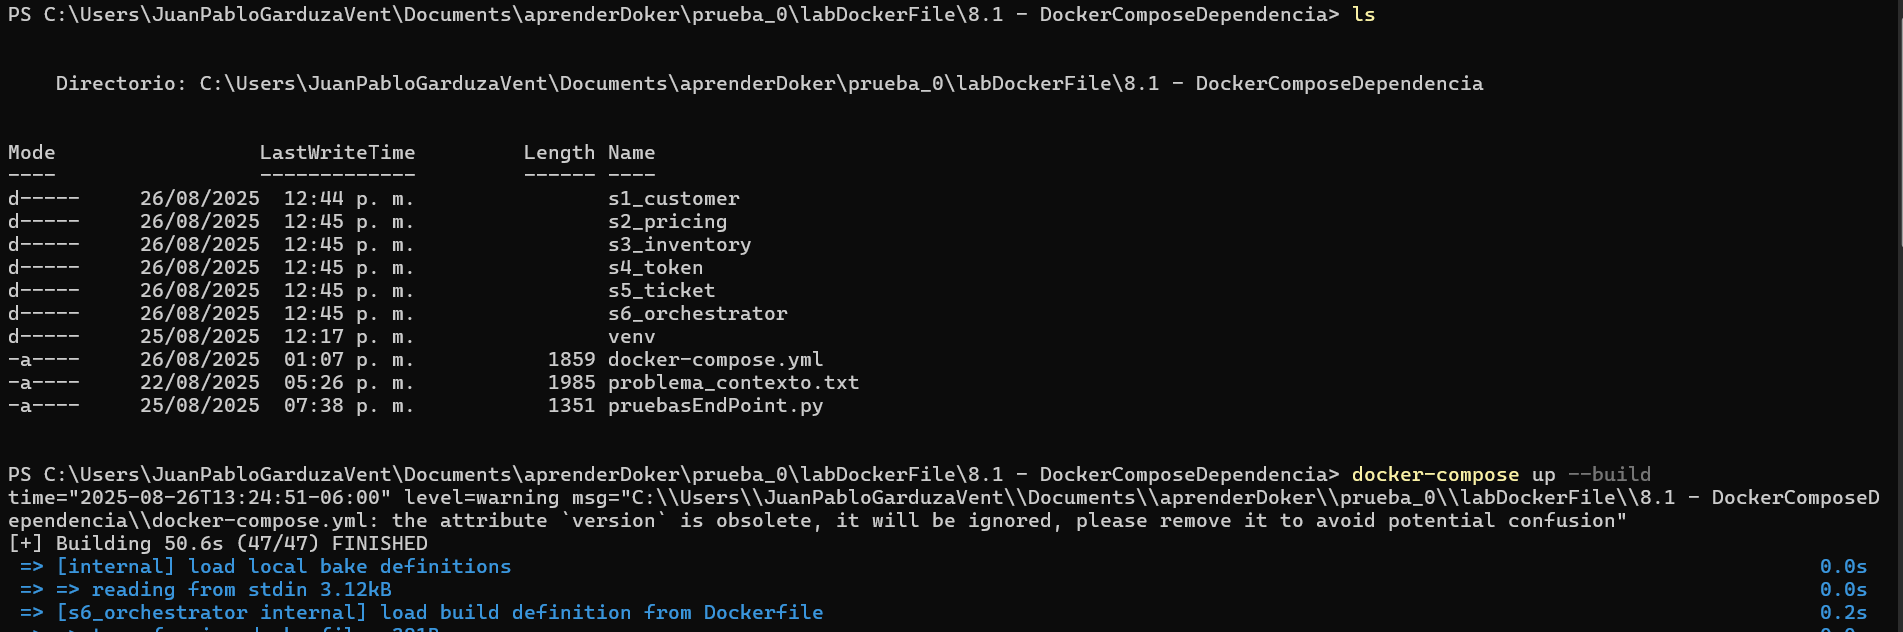

ahora vemos que:

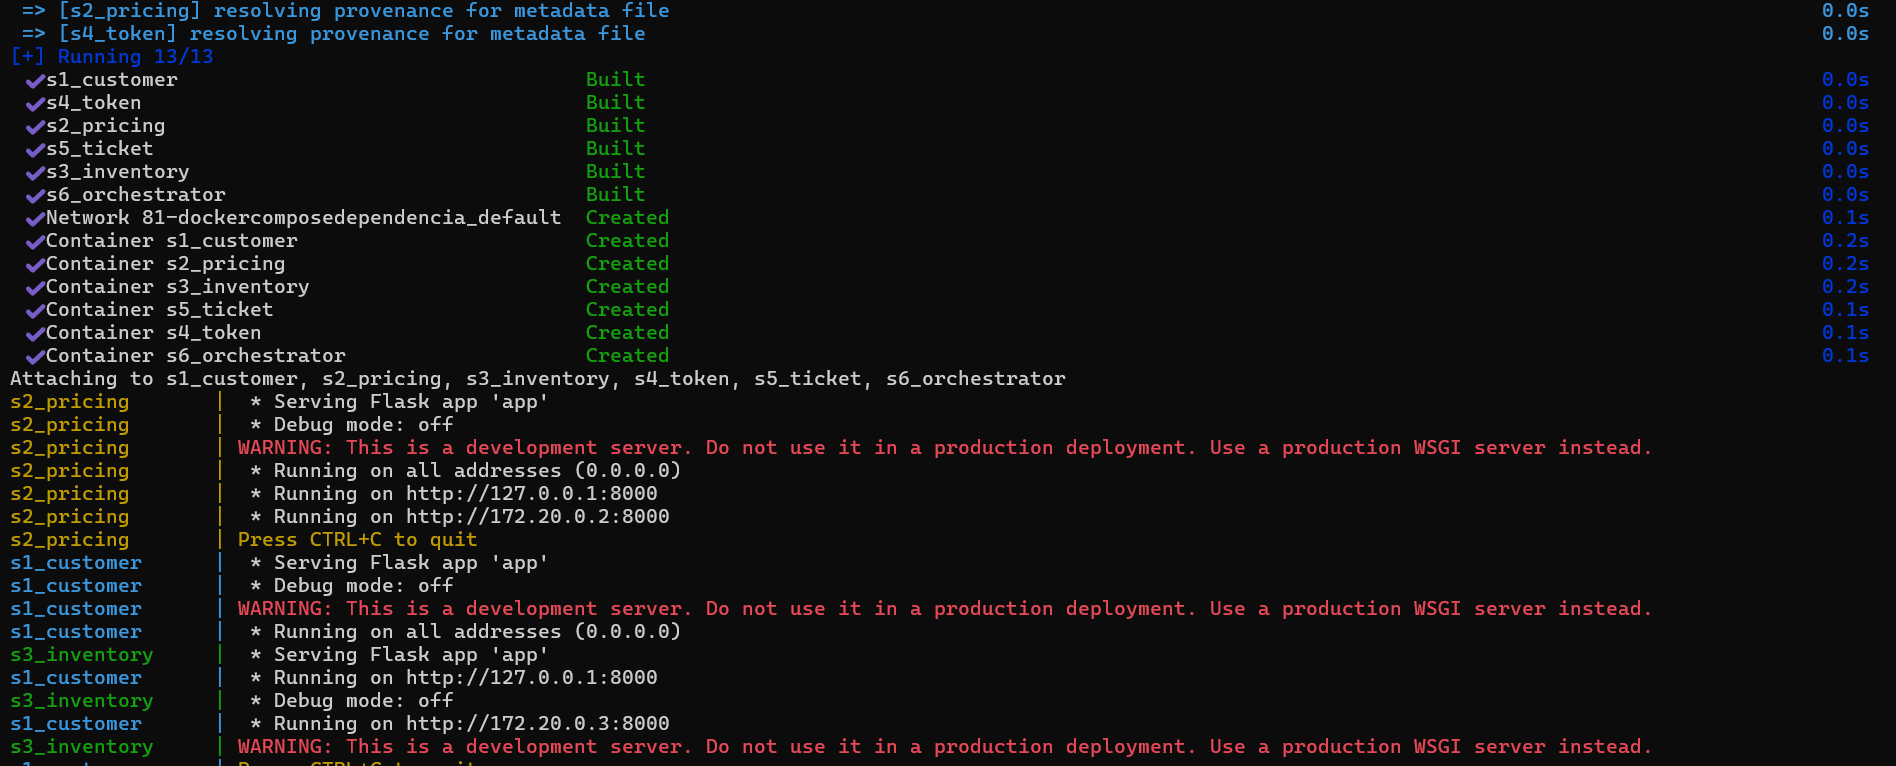



*Observamos*

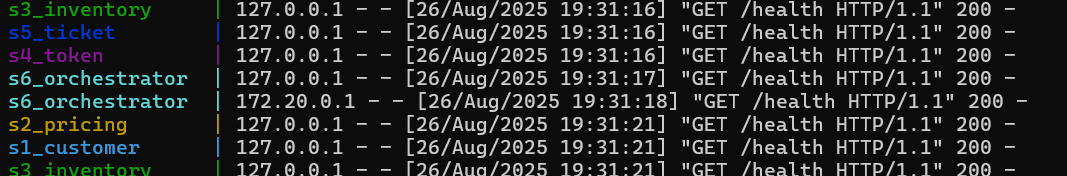

donde:

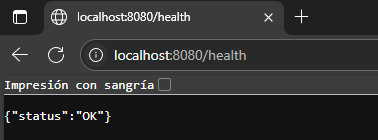

*puerto 8080 como lo menciona el docker-compose*

*Probamos json*

In [ ]:
import requests

# URL del endpoint
url_principal = "http://localhost:8080/run"

payload_process_principal = {
    "id": 123,
    "nombre": "Juan",
    "edad": 30,
    "producto": "Laptop",
    "precio": 1200,
    "descuento": 10,
    "categoria": "Electrónica",
    "stock": 5,
    "pais": "MX",
    "moneda": "USD"
  }

try:
    #--------------
    response_principal = requests.post(url_principal,json=payload_process_principal)
    print("Código de estado:", response_principal.status_code, type(response_principal.status_code))
    print("Respuesta JSON:", response_principal.json(), type(response_principal.json()))

except requests.exceptions.ConnectionError as e:
    print("No se pudo conectar con el servidor.")
    print("Detalles del error:", e)

except requests.exceptions.Timeout as e:
    print("La conexión tardó demasiado y se agotó el tiempo.")
    print("Detalles del error:", e)

except requests.exceptions.HTTPError as err:
    print(f"Error HTTP: {err}")

except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")
    print("Detalles del error:", e)


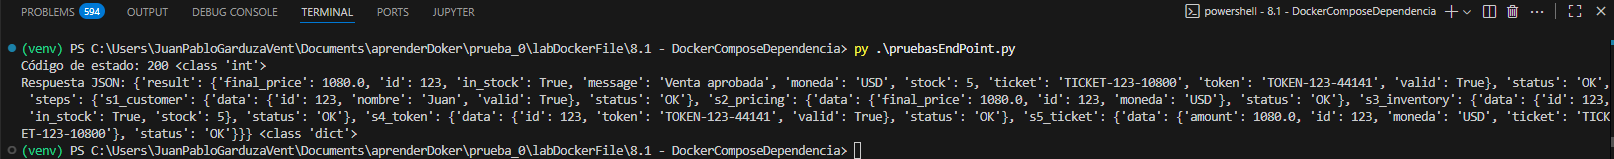

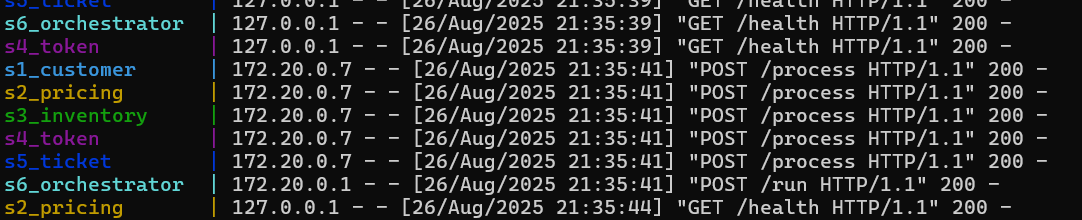

> EJEMPLO 3 - DockerCompose - Volumen (Dependemos del ejemplo 2)

Mantenemos el proyecto *ejemplo 2*

*Nota se modifica:*

* s4_token: guardara en un volumen de docker el json
* s6_orchestrator: agrega nuevas funciones para volumnes
* docker-compose

*se agrega:*

* s7_compra: guarda el tiket en local
* s8_reader: toma agrega el json de s4 al json final



> *INCIAMOS DOCKER SIN DOCKER-DESKTOP*

Instalamos (por defecto install ubuntu):

In [ ]:
wsl --install 

> buscar metodos response request y sus metodos

> TEMAS A BUSCAR

* DEfinir tam de contenedores de memorias

* enlazar contenedores

* workdir - dorckerfile ---Docker crea /app si no existe
WORKDIR /app
WORKDIR src

Esto te lleva a /app/src, y Docker crea ambos si no existen.

* comandos de que se ejecutan durante la construccion de imagen:
    * from, run, copy, add, workdir, env, label

* comandos de que se ejecutan al iniciar el contenedor:
    * cmd, entrypoint, healthchec, expose,volume

* ENTRYPOINT vs CMD (cómo y cuándo se sobreescriben)

* jenkins los necesarios
    
